# Neural Network + Charlson Comorbidity Index (CCI)
Feedforward neural network with CCI feature engineering for 30-day hospital readmission prediction using the Diabetes 130-US Hospitals dataset.

## Imports

In [6]:
import sys
import os
import numpy as np
import pandas as pd
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, roc_auc_score,
                             average_precision_score)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
sys.path.append(os.path.join(os.getcwd(), 'metrics'))
from fairness_audit import FairnessAuditor

## Charlson Comorbidity Index (CCI)
The CCI scores overall disease burden from raw ICD-9 diagnosis codes. Higher score means sicker patient. Weights from Quan et al. (2005). This is our specific engineered feature.

In [7]:
CCI_MAP = [
    ('250',  1, 'diabetes'),
    ('2504', 2, 'diabetes_complicated'),
    ('2505', 2, 'diabetes_complicated'),
    ('2506', 2, 'diabetes_complicated'),
    ('2507', 2, 'diabetes_complicated'),
    ('2508', 2, 'diabetes_complicated'),
    ('2509', 2, 'diabetes_complicated'),
    ('585',  2, 'renal'),
    ('428',  1, 'heart_failure'),
    ('440',  1, 'peripheral_vascular'),
]


def compute_cci(row):
    # sum weights across all diagnosis columns and count each condition once
    score = 0
    seen  = set()
    for code in row:
        if pd.isna(code) or code == '?':
            continue
        code = str(code).replace('.', '').strip()
        for prefix, weight, name in CCI_MAP:
            if name not in seen and code.startswith(prefix):
                score += weight
                seen.add(name)
    return score

## Data Loading
Load the UCI Diabetes 130-US Hospitals dataset, compute the CCI feature, and preprocess.

In [8]:
def load_data():
    print("Loading dataset...")
    raw = fetch_ucirepo(id=296)
    X   = raw.data.features.copy()
    y   = raw.data.targets.copy()

    y = (y['readmitted'] == '<30').astype(int).values

    # compute CCI before dropping diagnosis columns
    diag_cols      = [c for c in ['diag_1', 'diag_2', 'diag_3'] if c in X.columns]
    X['cci_score'] = X[diag_cols].apply(compute_cci, axis=1)
    print(f"CCI score -- mean: {X['cci_score'].mean():.2f}  max: {X['cci_score'].max()}")

    cols_to_drop = [
        'weight', 'payer_code', 'medical_specialty',
        'encounter_id', 'patient_nbr',
        'diag_1', 'diag_2', 'diag_3',
    ]
    X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

    # remove patients who died or went to hospice
    if 'discharge_disposition_id' in X.columns:
        dead_codes = [11, 13, 14, 19, 20, 21]
        mask = ~X['discharge_disposition_id'].isin(dead_codes)
        X    = X[mask]
        y    = y[mask]

    X = X.replace('?', np.nan)

    missing_frac = X.isnull().mean()
    X = X.drop(columns=missing_frac[missing_frac > 0.4].index)

    num_cols = X.select_dtypes(include=[np.number]).columns
    cat_cols = X.select_dtypes(exclude=[np.number]).columns

    # drop high cardinality categoricals
    high_cardinality = [c for c in cat_cols if X[c].nunique() > 20]
    X        = X.drop(columns=high_cardinality)
    cat_cols = [c for c in cat_cols if c not in high_cardinality]

    X[num_cols] = X[num_cols].fillna(X[num_cols].median())
    X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])
    X = pd.get_dummies(X, columns=list(cat_cols), drop_first=True)

    print(f"Final dataset: {X.shape[0]} rows, {X.shape[1]} features")
    print(f"Positive class (readmitted <30d): {y.mean()*100:.1f}%")

    return X.values, y


def load_data_with_demographics():
    # separate load that keeps race, gender, age for fairness audit
    # these are NOT used as model features -- only for subgroup evaluation
    raw  = fetch_ucirepo(id=296)
    X    = raw.data.features.copy()
    y    = raw.data.targets.copy()
    y    = (y['readmitted'] == '<30').astype(int).values

    demo = X[['race', 'gender', 'age']].copy()

    if 'discharge_disposition_id' in X.columns:
        dead_codes = [11, 13, 14, 19, 20, 21]
        mask = ~X['discharge_disposition_id'].isin(dead_codes)
        demo = demo[mask].reset_index(drop=True)
        y    = y[mask]

    return demo, y


X, y = load_data()

Loading dataset...


/usr/local/python/3.12.1/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


CCI score -- mean: 0.84  max: 6
Final dataset: 99343 rows, 77 features
Positive class (readmitted <30d): 11.4%


## Train/Test Split and Scaling

In [9]:
# track test indices so demographics align exactly with model predictions
indices = np.arange(len(X))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"pos_weight: {pos_weight:.2f}")
print(f"Majority class baseline accuracy: {(1 - y_test.mean())*100:.1f}%")

pos_weight: 7.78
Majority class baseline accuracy: 88.6%


## Model, Data Loader, and Training Loop

In [10]:
def make_data_loader(X, y, batch_size=256):
    return torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X, y),
        batch_size=batch_size,
        shuffle=True
    )


# nn.Sequential pipeline style from class notes
class ReadmissionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.pipeline = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)        # raw logit
        )

    def forward(self, x):
        return self.pipeline(x)


# training loop structure from class notes
def train(model, train_loader, pos_weight, k_epochs=30, lr=1e-3):
    loss_fn   = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loss = []

    for epoch in range(k_epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_loss.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{k_epochs} -- loss: {avg_loss:.4f}")

    return train_loss

## Train the Model

In [11]:
train_loader = make_data_loader(X_train_t, y_train_t)
model        = ReadmissionNet(input_dim=X_train_t.shape[1])

print("Training...")
train_loss = train(model, train_loader, pos_weight, k_epochs=30, lr=1e-3)

Training...
  Epoch  10/30 -- loss: 1.1432
  Epoch  20/30 -- loss: 1.1302
  Epoch  30/30 -- loss: 1.1213


## Evaluation

In [12]:
def evaluate(model, X_test, y_test, threshold=0.5):
    model.eval()
    X_t = torch.tensor(X_test, dtype=torch.float32)

    with torch.no_grad():
        probs = torch.sigmoid(model(X_t)).squeeze().numpy()

    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()

    sensitivity     = tp / (tp + fn) if (tp + fn) > 0 else 0
    ppv             = tp / (tp + fp) if (tp + fp) > 0 else 0
    auc_roc         = roc_auc_score(y_test, probs)
    auc_pr          = average_precision_score(y_test, probs)
    baseline_auc_pr = average_precision_score(y_test, np.zeros_like(y_test))

    print(f"\n--- Evaluation (threshold = {threshold}) ---")
    print(f"  Sensitivity (recall): {sensitivity:.3f}")
    print(f"  PPV (precision):      {ppv:.3f}")
    print(f"  AUC-ROC:              {auc_roc:.3f}")
    print(f"  AUC-PR:               {auc_pr:.3f}  (baseline: {baseline_auc_pr:.3f})")
    print(f"  Confusion matrix:")
    print(f"    TN={tn:6d}  FP={fp:6d}")
    print(f"    FN={fn:6d}  TP={tp:6d}")

    # evaluate at two additional clinical thresholds
    for t in [0.3, 0.4]:
        p = (probs >= t).astype(int)
        tn2, fp2, fn2, tp2 = confusion_matrix(y_test, p, labels=[0, 1]).ravel()
        s = tp2 / (tp2 + fn2) if (tp2 + fn2) > 0 else 0
        v = tp2 / (tp2 + fp2) if (tp2 + fp2) > 0 else 0
        print(f"\n  At threshold {t}: sensitivity={s:.3f}  PPV={v:.3f}  "
              f"TP={tp2}  FP={fp2}  FN={fn2}")

    return probs, {'sensitivity': sensitivity, 'ppv': ppv,
                   'auc_roc': auc_roc, 'auc_pr': auc_pr}


probs, metrics = evaluate(model, X_test, y_test, threshold=0.5)


--- Evaluation (threshold = 0.5) ---
  Sensitivity (recall): 0.553
  PPV (precision):      0.169
  AUC-ROC:              0.642
  AUC-PR:               0.203  (baseline: 0.114)
  Confusion matrix:
    TN= 11446  FP=  6160
    FN=  1011  TP=  1252

  At threshold 0.3: sensitivity=0.909  PPV=0.128  TP=2058  FP=14024  FN=205

  At threshold 0.4: sensitivity=0.760  PPV=0.144  TP=1721  FP=10242  FN=542


## Training Loss

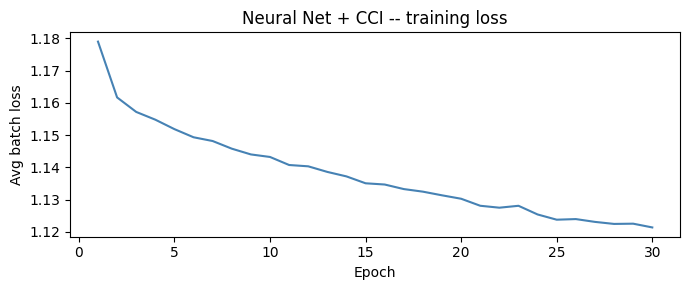

Saved: nn_training_loss.png


In [13]:
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(train_loss) + 1), train_loss,
         color='steelblue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Avg batch loss')
plt.title('Neural Net + CCI -- training loss')
plt.tight_layout()
plt.savefig('nn_training_loss.png', dpi=150)
plt.show()
print("Saved: nn_training_loss.png")

## Confusion Matrix

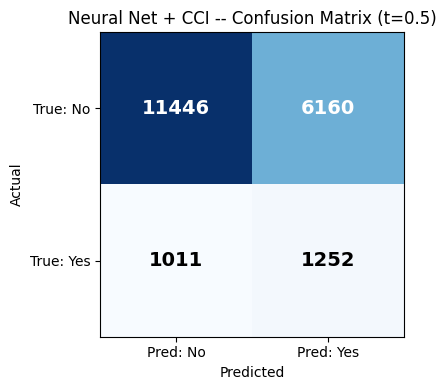

Saved: nn_confusion_matrix.png


In [14]:
preds = (probs >= 0.5).astype(int)
cm    = confusion_matrix(y_test, preds, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred: No', 'Pred: Yes'])
ax.set_yticklabels(['True: No', 'True: Yes'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Neural Net + CCI -- Confusion Matrix (t=0.5)')

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('nn_confusion_matrix.png', dpi=150)
plt.show()
print("Saved: nn_confusion_matrix.png")

## Sensitivity vs PPV Threshold Sweep

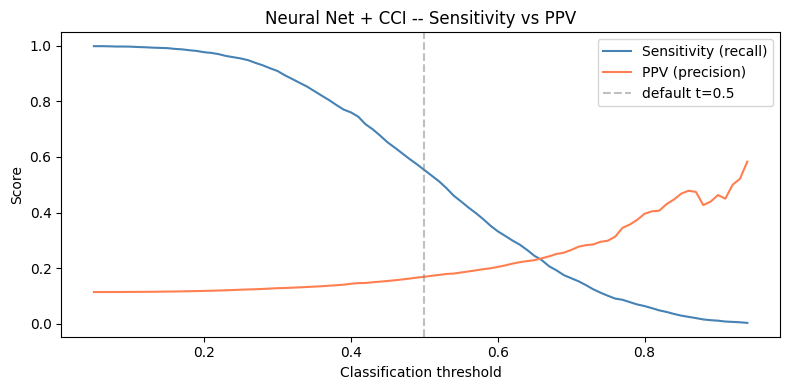

Saved: nn_threshold_sweep.png


In [15]:
thresholds    = np.arange(0.05, 0.95, 0.01)
sensitivities = []
ppvs          = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    if preds.sum() == 0:
        sensitivities.append(0)
        ppvs.append(0)
        continue
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()
    sensitivities.append(tp / (tp + fn + 1e-9))
    ppvs.append(tp / (tp + fp + 1e-9))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, sensitivities, label='Sensitivity (recall)', color='steelblue')
plt.plot(thresholds, ppvs,          label='PPV (precision)',      color='coral')
plt.axvline(0.5, linestyle='--', color='gray', alpha=0.5, label='default t=0.5')
plt.xlabel('Classification threshold')
plt.ylabel('Score')
plt.title('Neural Net + CCI -- Sensitivity vs PPV')
plt.legend()
plt.tight_layout()
plt.savefig('nn_threshold_sweep.png', dpi=150)
plt.show()
print("Saved: nn_threshold_sweep.png")

## Calibration Plot

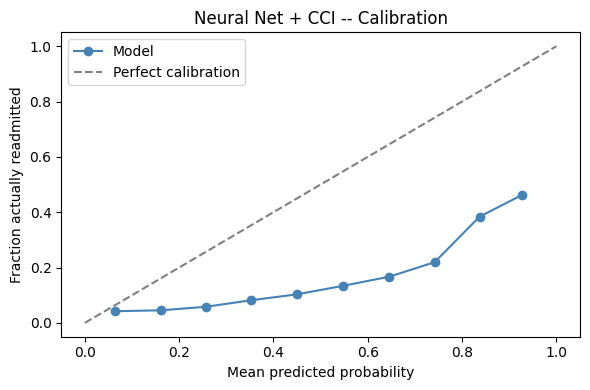

Saved: nn_calibration.png


In [16]:
fraction_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)

plt.figure(figsize=(6, 4))
plt.plot(mean_pred, fraction_pos, marker='o', color='steelblue', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction actually readmitted')
plt.title('Neural Net + CCI -- Calibration')
plt.legend()
plt.tight_layout()
plt.savefig('nn_calibration.png', dpi=150)
plt.show()
print("Saved: nn_calibration.png")

## Fairness Audit
Breaks down AUROC by race, gender, and age. Demographics are loaded separately and never used as model features.

Loading demographics for fairness audit...


/usr/local/python/3.12.1/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)



  Neural Net + CCI  |  Overall AUROC=0.6418

  ── Race
    AfricanAmerican      N=3809.0 AUROC=0.636  Recall=0.539  PPR=0.375 !
    Asian                N=128.0  AUROC=0.754  Recall=0.500  PPR=0.250
    Caucasian            N=14743.0 AUROC=0.643  Recall=0.565  PPR=0.380 !
    Hispanic             N=410.0  AUROC=0.737  Recall=0.688  PPR=0.368
    Other                N=304.0  AUROC=0.545  Recall=0.300  PPR=0.257 !

  ── Gender
    Female               N=10651.0 AUROC=0.631  Recall=0.545  PPR=0.373
    Male                 N=9218.0 AUROC=0.654  Recall=0.563  PPR=0.372

  ── Age
    [10-20)              N=146.0  AUROC=0.629  Recall=0.200  PPR=0.048 !
    [20-30)              N=338.0  AUROC=0.785  Recall=0.683  PPR=0.328
    [30-40)              N=721.0  AUROC=0.723  Recall=0.653  PPR=0.361 !
    [40-50)              N=1943.0 AUROC=0.683  Recall=0.540  PPR=0.299 !
    [50-60)              N=3378.0 AUROC=0.662  Recall=0.445  PPR=0.250 !
    [60-70)              N=4496.0 AUROC=0.631  Recall

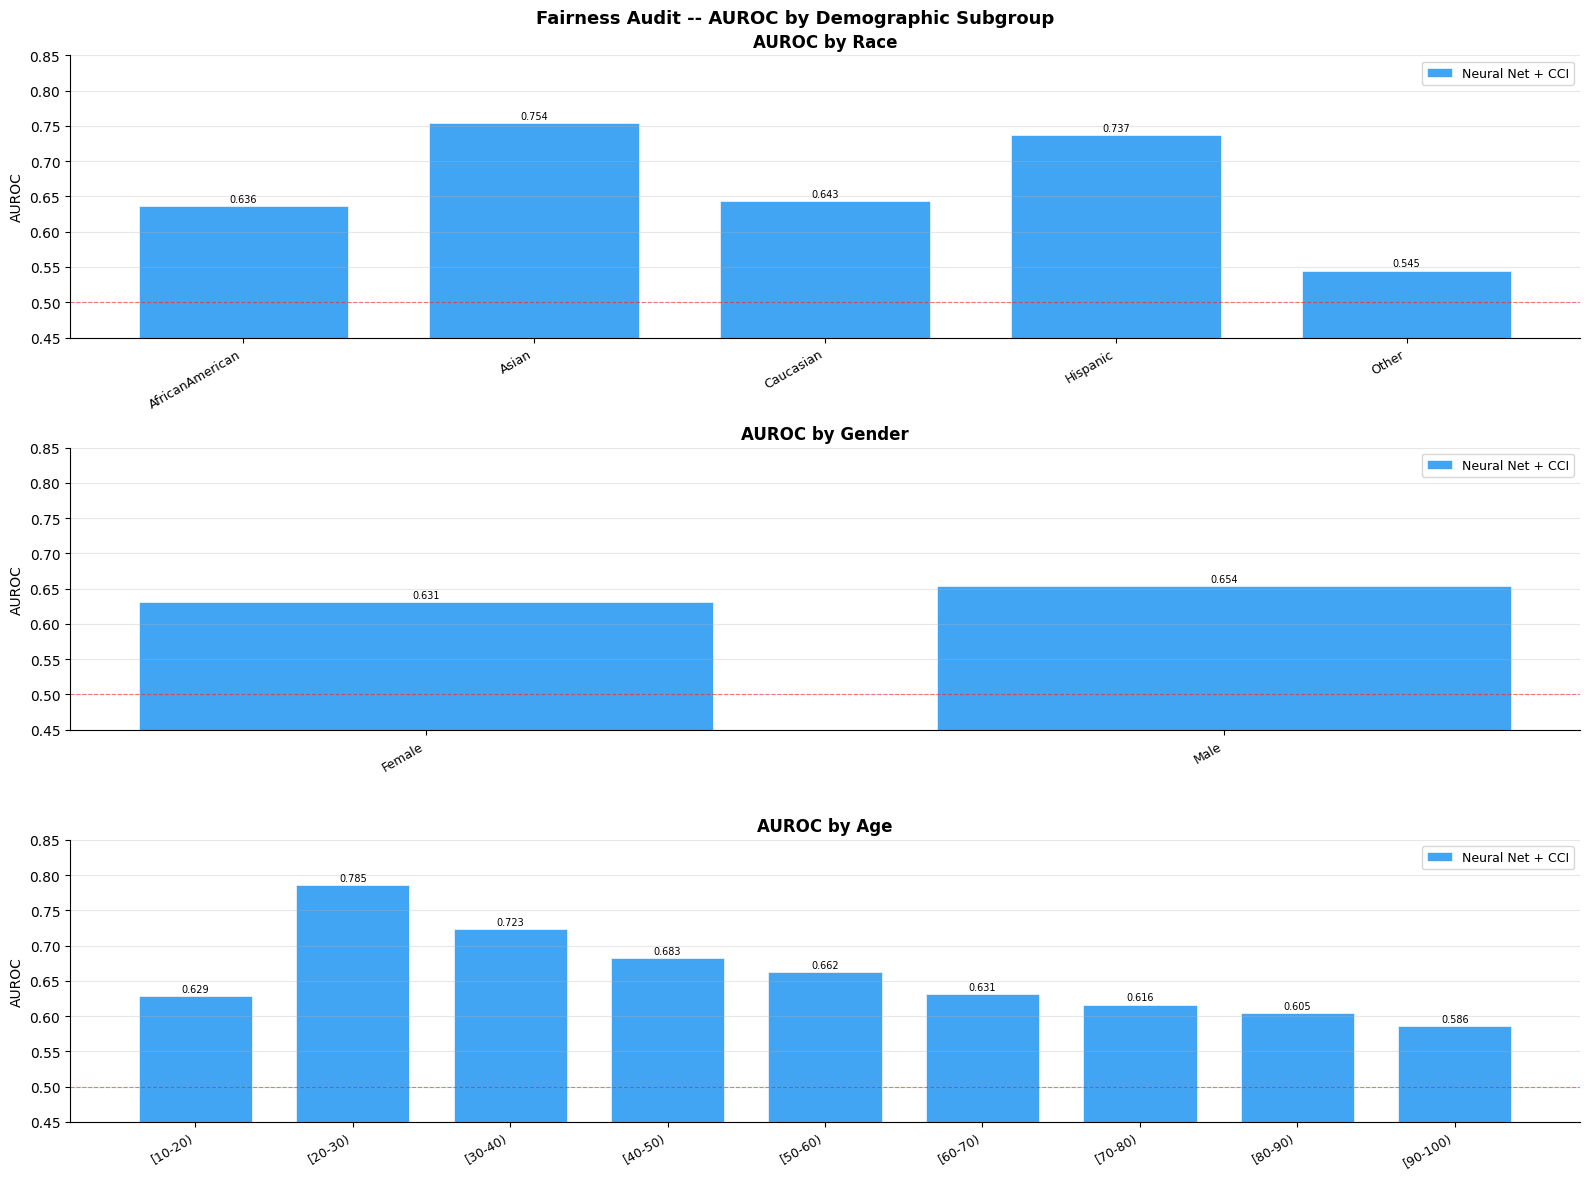

Saved: nn_fairness_audit.png


In [17]:
def plot_fairness_audit(auditor):
    # plots AUROC by demographic subgroup and saves as png
    labels = [l for l in auditor.SUBGROUPS if any(
        l in auditor.results.get(m, {}) for m in auditor.models
    )]
    colors = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0"]
    fig, axes = plt.subplots(len(labels), 1, figsize=(16, 12))
    if len(labels) == 1:
        axes = [axes]

    for ax, label in zip(axes, labels):
        subgroups = list(dict.fromkeys(
            sg for m in auditor.models
            for sg in auditor.results.get(m, {}).get(label, pd.DataFrame()).index
        ))
        if not subgroups:
            continue

        x     = np.arange(len(subgroups))
        width = 0.8 / len(auditor.models)

        for i, (name, color) in enumerate(zip(auditor.models, colors)):
            df     = auditor.results.get(name, {}).get(label, pd.DataFrame())
            aurocs = [df.loc[sg, "auroc"] if sg in df.index else np.nan
                      for sg in subgroups]
            offset = (i - len(auditor.models) / 2 + 0.5) * width
            bars   = ax.bar(x + offset, aurocs, width * 0.9,
                            label=name, color=color, alpha=0.85,
                            edgecolor="white", linewidth=0.5)
            for bar, val in zip(bars, aurocs):
                if not np.isnan(val):
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 0.003, f"{val:.3f}",
                            ha="center", va="bottom", fontsize=7)

        ax.set_xticks(x)
        ax.set_xticklabels(subgroups, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("AUROC")
        ax.set_title(f"AUROC by {label}", fontweight="bold")
        ax.set_ylim(0.45, 0.85)
        ax.axhline(0.5, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Fairness Audit -- AUROC by Demographic Subgroup",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig('nn_fairness_audit.png', dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: nn_fairness_audit.png")


print("Loading demographics for fairness audit...")
demo, y_demo = load_data_with_demographics()
demo_test    = demo.iloc[idx_test].reset_index(drop=True)

auditor = FairnessAuditor(
    X_demo    = demo_test,
    y_test    = y_test,
    threshold = 0.5,
    gap       = 0.05
)
auditor.add_model("Neural Net + CCI", probs)
auditor.run_audit()
auditor.summary()
plot_fairness_audit(auditor)

## Save Model Weights

In [18]:
torch.save(model.state_dict(), 'neural_net_cci.pth')
print("Model saved: neural_net_cci.pth")

Model saved: neural_net_cci.pth
